https://www.tutorialspoint.com/keras/keras_real_time_prediction_using_resnet_model.htm

https://deeplearning.cms.waikato.ac.nz/user-guide/class-maps/IMAGENET/

https://gist.github.com/aaronpolhamus/964a4411c0906315deb9f4a3723aac57

Import modules

In [ ]:
import PIL 
from tensorflow.keras.preprocessing.image import load_img 
from tensorflow.keras.preprocessing.image import img_to_array 
from tensorflow.keras.applications.imagenet_utils import decode_predictions 
import matplotlib.pyplot as plt 
import numpy as np 
from tensorflow.keras.applications.resnet50 import ResNet50 
from tensorflow.keras.applications import resnet50


Select an input

PIL image size (224, 224)


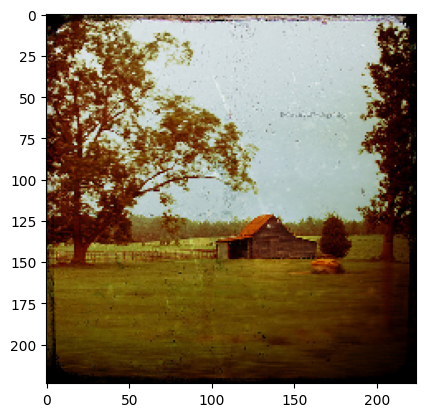

In [5]:
filename = '../images/barn.JPEG' 
## load an image in PIL format 
original = load_img(filename, target_size = (224, 224)) 
print('PIL image size',original.size)
# PIL image size (224, 224) 
plt.imshow(original) 
# <matplotlib.image.AxesImage object at 0x1304756d8> 
plt.show()

Convert images into NumPy array

numpy array size (224, 224, 3)
image batch size (1, 224, 224, 3)


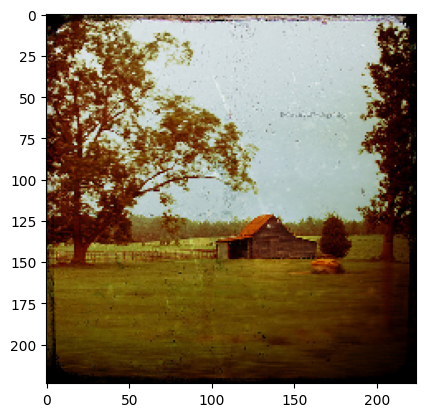

In [6]:
#convert the PIL image to a numpy array 
numpy_image = img_to_array(original) 

plt.imshow(np.uint8(numpy_image)) 
# <matplotlib.image.AxesImage object at 0x130475ac8> 

print('numpy array size',numpy_image.shape) 
# numpy array size (224, 224, 3) 

# Convert the image / images into batch format 
image_batch = np.expand_dims(numpy_image, axis = 0) 

print('image batch size', image_batch.shape) 
# image batch size (1, 224, 224, 3)


Model prediction

In [ ]:
# prepare the image for the resnet50 model >>> 
processed_image = resnet50.preprocess_input(image_batch.copy()) 

# create resnet model 
resnet_model = resnet50.ResNet50(weights = 'imagenet') 

# get the predicted probabilities for each class 
predictions = resnet_model.predict(processed_image) 

# convert the probabilities to class labels 
label = decode_predictions(predictions) 


print(label)

1/1 [==============================] - 1s 603ms/step
[[('n09332890', 'lakeside', 0.47736016), ('n02793495', 'barn', 0.24485794), ('n02859443', 'boathouse', 0.084395304), ('n03930313', 'picket_fence', 0.07177587), ('n03028079', 'church', 0.025269793)]]
